# CODE TO CLASSIFY TRAFFIC SIGNS USING LE-NET ARCHITECTURE IN KERAS

- In this case study, you have been provided with images of traffic signs and the goal is to train a Deep Network to classify them
- The dataset contains 43 different classes of images. 
- Classes are as listed below: 

    - ( 0, b'Speed limit (20km/h)') ( 1, b'Speed limit (30km/h)')
    - ( 2, b'Speed limit (50km/h)') ( 3, b'Speed limit (60km/h)')
    - ( 4, b'Speed limit (70km/h)') ( 5, b'Speed limit (80km/h)')
    - ( 6, b'End of speed limit (80km/h)') ( 7, b'Speed limit (100km/h)')
    - ( 8, b'Speed limit (120km/h)') ( 9, b'No passing')
    - (10, b'No passing for vehicles over 3.5 metric tons')
    - (11, b'Right-of-way at the next intersection') (12, b'Priority road')
    - (13, b'Yield') (14, b'Stop') (15, b'No vehicles')
    - (16, b'Vehicles over 3.5 metric tons prohibited') (17, b'No entry')
    - (18, b'General caution') (19, b'Dangerous curve to the left')
    - (20, b'Dangerous curve to the right') (21, b'Double curve')
    - (22, b'Bumpy road') (23, b'Slippery road')
    - (24, b'Road narrows on the right') (25, b'Road work')
    - (26, b'Traffic signals') (27, b'Pedestrians') (28, b'Children crossing')
    - (29, b'Bicycles crossing') (30, b'Beware of ice/snow')
    - (31, b'Wild animals crossing')
    - (32, b'End of all speed and passing limits') (33, b'Turn right ahead')
    - (34, b'Turn left ahead') (35, b'Ahead only') (36, b'Go straight or right')
    - (37, b'Go straight or left') (38, b'Keep right') (39, b'Keep left')
    - (40, b'Roundabout mandatory') (41, b'End of no passing')
    - (42, b'End of no passing by vehicles over 3.5 metric tons')3
    

# STEP 1: IMPORT LIBRARIES AND DATASET

In [ ]:
import pandas as pd 
import numpy as np 
import pickle   
import matplotlib.pyplot as plt

In [ ]:
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# The pickle module implements binary protocols for serializing and de-serializing a Python object structure.
with open("./DataSource/train.p", mode='rb') as training_data:
    train = pickle.load(training_data)
with open("./DataSource/valid.p", mode='rb') as validation_data:
    valid = pickle.load(validation_data)
with open("./DataSource/test.p", mode='rb') as testing_data:
    test = pickle.load(testing_data)

In [ ]:
X_train,y_train=train['features'],train['labels']
X_validation,y_validation=valid['features'],valid['labels']
X_test,y_test=test['features'],test['labels']

In [ ]:
X_train.shape

In [ ]:
y_train.shape

In [ ]:
X_validation.shape

In [ ]:
y_validation.shape

In [ ]:
X_test.shape

In [ ]:
y_test.shape

# STEP 2: IMAGE EXPLORATION

In [ ]:
i=3000
plt.imshow(X_train[i])
y_train[i]

In [ ]:
i=3000
plt.imshow(X_validation[i])
y_validation[i]

In [ ]:
i=2000
plt.imshow(X_test[i])
y_test[i]

# STEP 3: DATA PEPARATION

In [ ]:
## shuffle the data 
from sklearn.utils import shuffle
X_train,y_train=shuffle(X_train,y_train)


In [ ]:
X_train_gray=np.sum(X_train/3,axis=3,keepdims=True)
X_validation_gray=np.sum(X_validation/3,axis=3,keepdims=True)
X_test_gray=np.sum(X_test/3,axis=3,keepdims=True)

In [ ]:
X_train_gray.shape,X_validation_gray.shape,X_test_gray.shape

In [ ]:
#normalization
X_train_gray_norm=(X_train_gray-128)/128
X_validation_gray_norm=(X_validation_gray-128)/128
X_test_gray_norm=(X_test_gray-128)/128

In [ ]:
#squeeze function removes single-dimensional entries from the shape of an array.
i=956
plt.imshow(X_train_gray_norm[i].squeeze(),cmap='gray')
plt.figure()
plt.imshow(X_train[i])
plt.figure()
plt.imshow(X_train_gray[i].squeeze(),cmap='gray')

In [ ]:
i=956
plt.imshow(X_test_gray_norm[i].squeeze(),cmap='gray')
plt.figure()
plt.imshow(X_test[i])
plt.figure()
plt.imshow(X_test_gray[i].squeeze(),cmap='gray')

In [ ]:
i=956
plt.imshow(X_validation_gray_norm[i].squeeze(),cmap='gray')
plt.figure()
plt.imshow(X_validation[i])
plt.figure()
plt.imshow(X_validation_gray[i].squeeze(),cmap='gray')

In [ ]:
# STEP 4: MODEL TRAINING

The model consists of the following layers: 

- STEP 1: THE FIRST CONVOLUTIONAL LAYER #1
    - Input = 32x32x1
    - Output = 28x28x6
    - Output = (Input-filter+1)/Stride* => (32-5+1)/1=28
    - Used a 5x5 Filter with input depth of 3 and output depth of 6
    - Apply a RELU Activation function to the output
    - pooling for input, Input = 28x28x6 and Output = 14x14x6


    * Stride is the amount by which the kernel is shifted when the kernel is passed over the image.

- STEP 2: THE SECOND CONVOLUTIONAL LAYER #2
    - Input = 14x14x6
    - Output = 10x10x16
    - Layer 2: Convolutional layer with Output = 10x10x16
    - Output = (Input-filter+1)/strides => 10 = 14-5+1/1
    - Apply a RELU Activation function to the output
    - Pooling with Input = 10x10x16 and Output = 5x5x16

- STEP 3: FLATTENING THE NETWORK
    - Flatten the network with Input = 5x5x16 and Output = 400

- STEP 4: FULLY CONNECTED LAYER
    - Layer 3: Fully Connected layer with Input = 400 and Output = 120
    - Apply a RELU Activation function to the output

- STEP 5: ANOTHER FULLY CONNECTED LAYER
    - Layer 4: Fully Connected Layer with Input = 120 and Output = 84
    - Apply a RELU Activation function to the output

- STEP 6: FULLY CONNECTED LAYER
    - Layer 5: Fully Connected layer with Input = 84 and Output = 43

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D,AveragePooling2D, Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import TensorBoard

In [27]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

cnn_model = Sequential()

# First block
cnn_model.add(Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(32,32,1)))
cnn_model.add(BatchNormalization())
cnn_model.add(Conv2D(32, (3,3), activation='relu'))
cnn_model.add(BatchNormalization())
cnn_model.add(MaxPooling2D(pool_size=(2,2)))
cnn_model.add(Dropout(0.25))

# Second block
cnn_model.add(Conv2D(64, (3,3), padding='same', activation='relu'))
cnn_model.add(BatchNormalization())
cnn_model.add(Conv2D(64, (3,3), activation='relu'))
cnn_model.add(BatchNormalization())
cnn_model.add(MaxPooling2D(2,2))
cnn_model.add(Dropout(0.25))

# Third block
cnn_model.add(Conv2D(128, (3,3), padding='same', activation='relu'))
cnn_model.add(BatchNormalization())
cnn_model.add(Conv2D(128, (3,3), activation='relu'))
cnn_model.add(BatchNormalization())
cnn_model.add(MaxPooling2D(2,2))
cnn_model.add(Dropout(0.4))

# Classifier
cnn_model.add(Flatten())
cnn_model.add(Dense(256, activation='relu'))
cnn_model.add(Dropout(0.5))
cnn_model.add(Dense(43, activation='softmax'))




In [28]:
from tensorflow.keras.optimizers import Adam

cnn_model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 30, 30, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 15, 15, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 15, 15, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 13, 13, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 13, 13, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 6, 6, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 6, 6, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 4, 4, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 4, 4, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 43)             │        11,05

 Total params: 430,603 (1.64 MB)

 Trainable params: 429,707 (1.64 MB)

 Non-trainable params: 896 (3.50 KB)

In [29]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

callbacks = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1),
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1)
]

history = cnn_model.fit(
    X_train_gray_norm,
    y_train,
    batch_size=64,
    epochs=40,
    validation_data=(X_validation_gray_norm, y_validation),
    callbacks=callbacks,
    verbose=1
)


Epoch 1/40
544/544 ━━━━━━━━━━━━━━━━━━━━ 64s 110ms/step - accuracy: 0.3614 - loss: 2.4538 - val_accuracy: 0.7655 - val_loss: 0.8007 - learning_rate: 5.0000e-04
Epoch 2/40
544/544 ━━━━━━━━━━━━━━━━━━━━ 65s 119ms/step - accuracy: 0.8253 - loss: 0.5543 - val_accuracy: 0.9488 - val_loss: 0.1514 - learning_rate: 5.0000e-04
Epoch 3/40
544/544 ━━━━━━━━━━━━━━━━━━━━ 60s 111ms/step - accuracy: 0.9314 - loss: 0.2149 - val_accuracy: 0.9617 - val_loss: 0.1275 - learning_rate: 5.0000e-04
Epoch 4/40
544/544 ━━━━━━━━━━━━━━━━━━━━ 60s 111ms/step - accuracy: 0.9614 - loss: 0.1233 - val_accuracy: 0.9839 - val_loss: 0.0622 - learning_rate: 5.0000e-04
Epoch 5/40
544/544 ━━━━━━━━━━━━━━━━━━━━ 69s 127ms/step - accuracy: 0.9746 - loss: 0.0838 - val_accuracy: 0.9764 - val_loss: 0.0815 - learning_rate: 5.0000e-04
Epoch 6/40
544/544 ━━━━━━━━━━━━━━━━━━━━ 65s 120ms/step - accuracy: 0.9804 - loss: 0.0629 - val_accuracy: 0.9814 - val_loss: 0.0639 - learning_rate: 5.0000e-04
Epoch 7/40
544/544 ━━━━━━━━━━━━━━━━━━━━ 67s 12

# STEP 5: MODEL EVALUATION

In [30]:
score=cnn_model.evaluate(X_test_gray_norm,y_test,verbose=0)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

Test loss: 0.07685354351997375
Test accuracy: 0.9825811386108398


In [31]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss', 'learning_rate'])

In [32]:
accuracy=history.history['accuracy']
val_accuracy=history.history['val_accuracy']
loss=history.history['loss']
val_loss=history.history['val_loss']

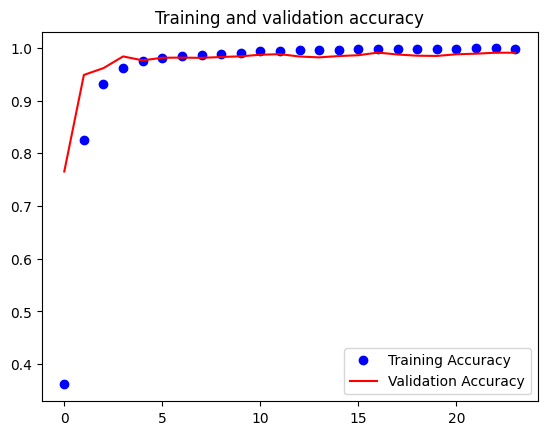

In [33]:
epochs=range(len(accuracy))
plt.plot(epochs,accuracy,'bo',label='Training Accuracy')
plt.plot(epochs,val_accuracy,'r',label='Validation Accuracy')
plt.title('Training and validation accuracy')
plt.legend()

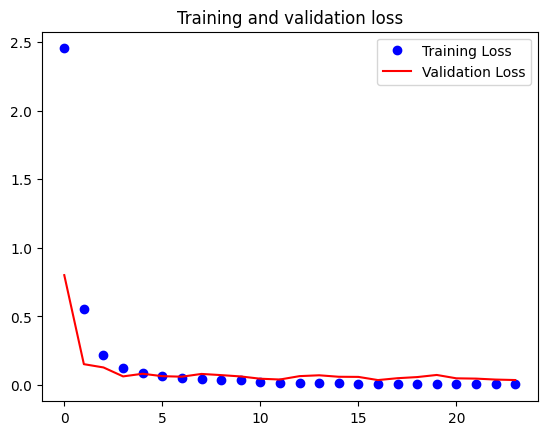

In [34]:
epochs=range(len(loss)) 
plt.plot(epochs,loss,'bo',label='Training Loss')
plt.plot(epochs,val_loss,'r',label='Validation Loss')
plt.title('Training and validation loss')
plt.legend()

In [35]:
predicted_probs=cnn_model.predict(X_test_gray_norm)
predicted_classes=np.argmax(predicted_probs,axis=1)

395/395 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step


In [36]:
print(predicted_probs.shape, predicted_classes.shape, y_test.shape)


(12630, 43) (12630,) (12630,)


In [37]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,predicted_classes)

In [39]:
import seaborn as sns

Text(220.72222222222223, 0.5, 'True Label')

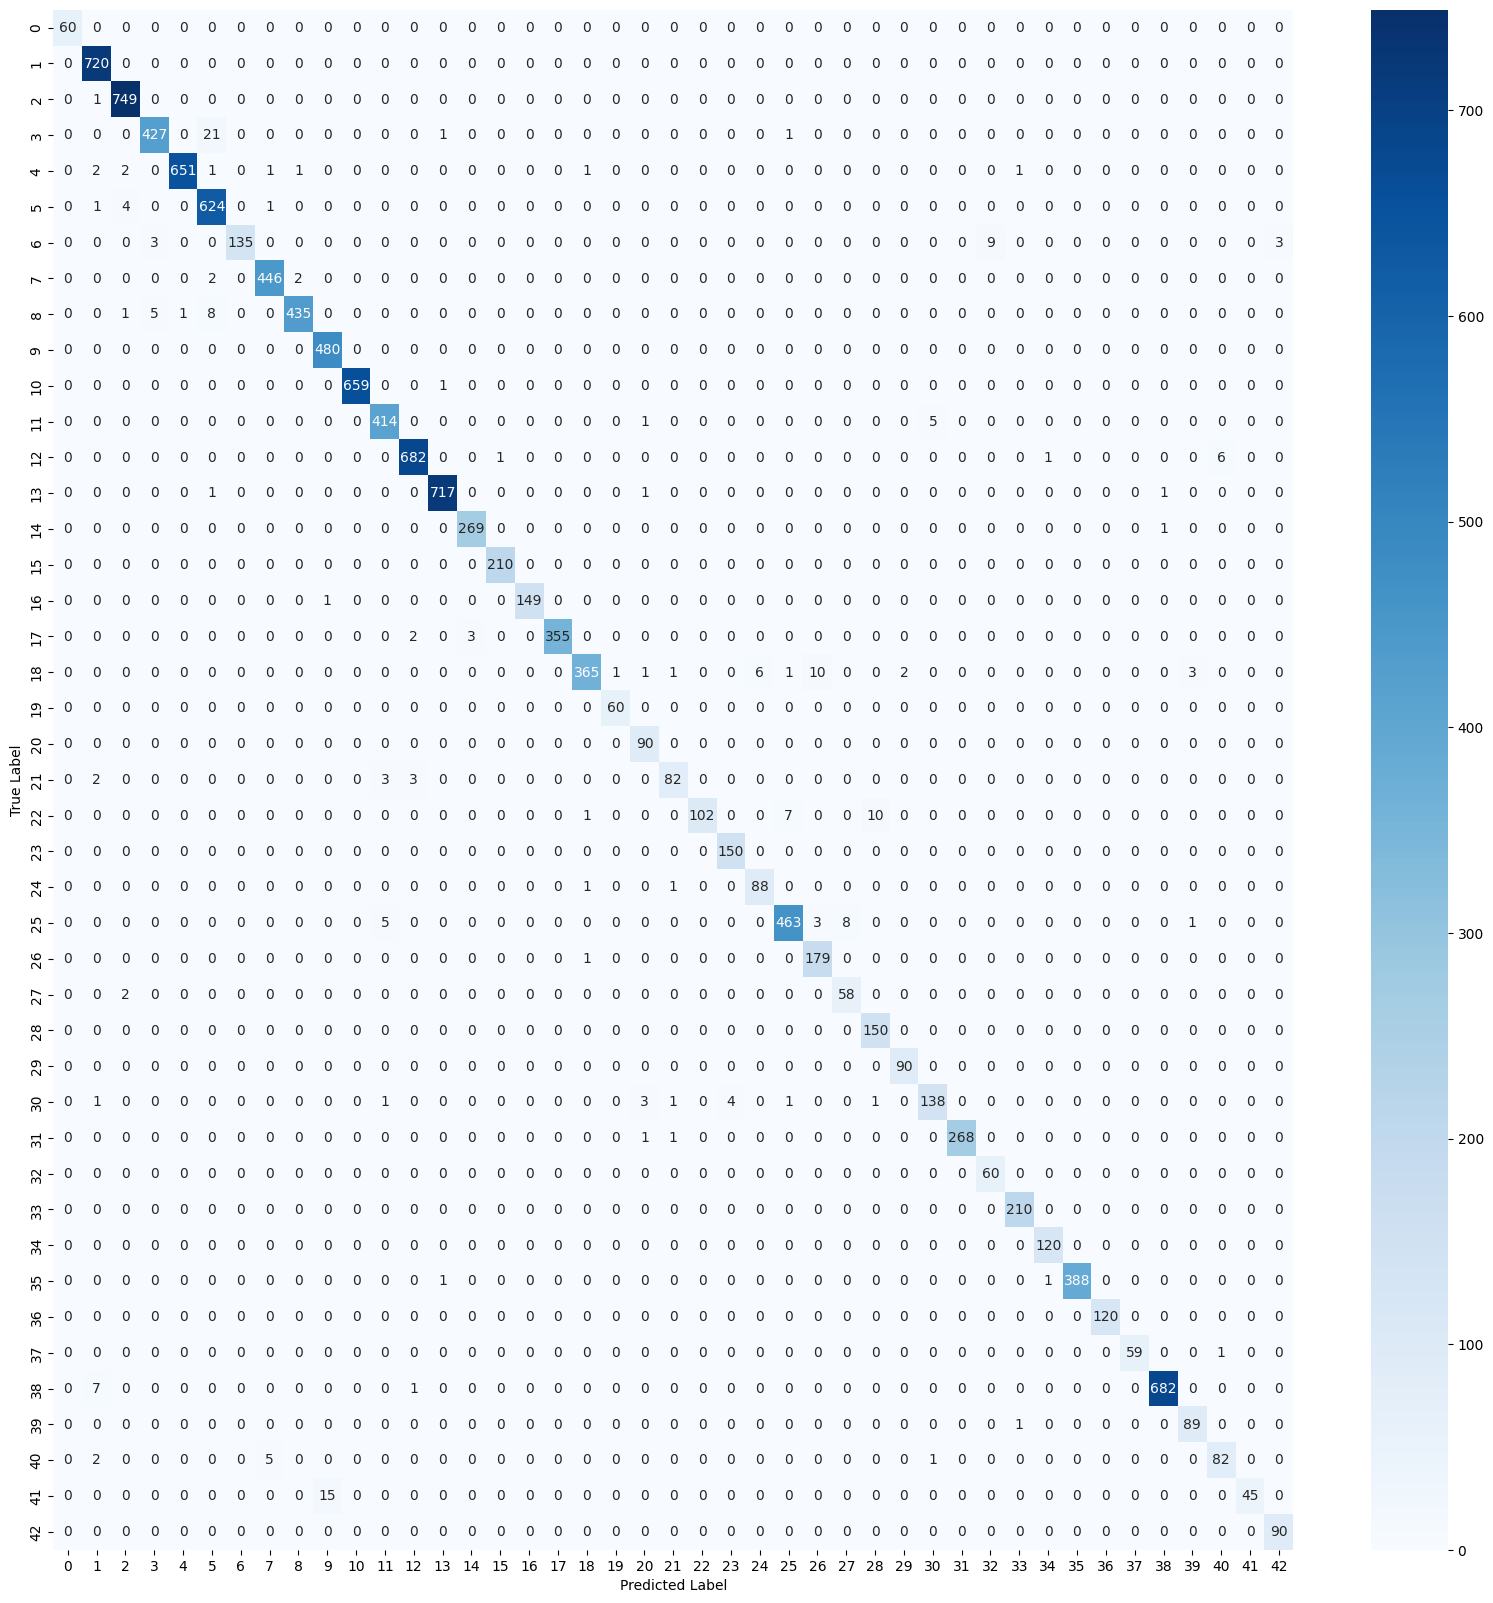

In [40]:
plt.figure(figsize=(20,20))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

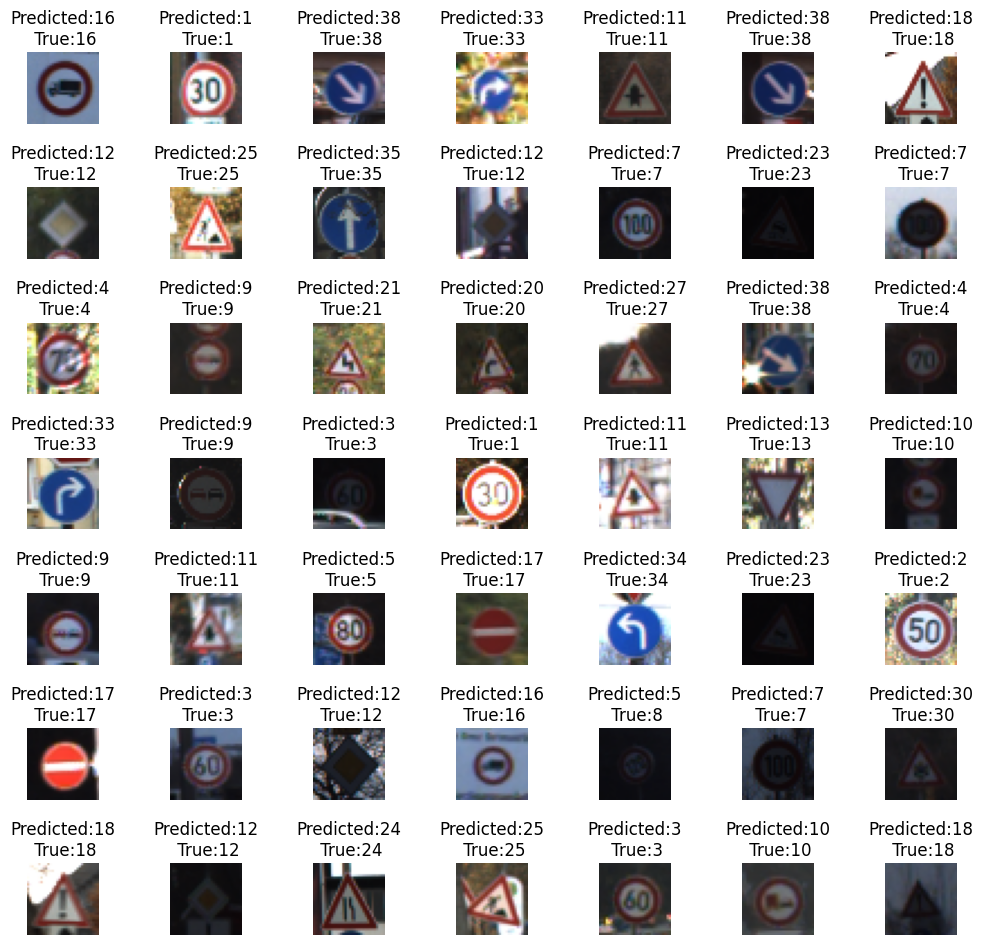

In [41]:
L=7
W=7
fig,axes=plt.subplots(L,W,figsize=(12,12))
axes=axes.ravel()

for i in np.arange(0,L*W):
    axes[i].imshow(X_test[i])
    axes[i].set_title(f"Predicted:{predicted_classes[i]}\n True:{y_test[i]}")
    axes[i].axis('off')

plt.subplots_adjust(wspace=1)

In [42]:
cnn_model.save("model.keras")